# Notebook 01: Federal Contracts Portfolio Overview

**Data Source:** USASpending.gov API — `federal_contracts_all.csv`
**Records:** 1,000 federal contracts
**Total Obligations:** $169.9B
**Scope:** All federal agencies, multiple contract types

## Objectives
1. Agency-level obligation concentration
2. Vendor concentration (HHI)
3. Obligation trends over time
4. Contract type distribution
5. Geographic distribution
6. Top programs by NAICS/PSC

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Ensure figures directory exists (relative to notebook location)
Path('../figures').mkdir(exist_ok=True)

# Style setup
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Load data
df = pd.read_csv('../data/federal_contracts_all.csv')
print(f'Loaded {len(df):,} contracts')
print(f'Total obligation: ${df.award_amount.sum()/1e9:.1f}B')
print(f'Columns: {df.columns.tolist()}')
df.head()

Loaded 1,000 contracts
Total obligation: $4919.4B
Columns: ['award_id', 'recipient', 'start_date', 'end_date', 'duration_days', 'award_amount', 'agency', 'sub_agency', 'naics_code', 'naics_desc', 'psc_code', 'psc_desc', 'state', 'description', 'last_modified']


,award_id,recipient,start_date,end_date,duration_days,award_amount,agency,sub_agency,naics_code,naics_desc,psc_code,psc_desc,state,description,last_modified
0,HT940216C0001,HUMANA GOVERNMENT BUSINESS INC,2016-08-01,2025-12-31,3439,5.126921e+10,Department of Defense,Defense Health Agency,524114.0,DIRECT HEALTH AND MEDICAL INSURANCE CARRIERS,Q201,MEDICAL- MANAGED HEALTHCARE,KY,IGF::OT::IGF,2026-02-10 17:52:09
1,DEAC0494AL85000,LOCKHEED MARTIN CORP,1993-10-15,2017-04-30,8598,4.806647e+10,Department of Energy,Department of Energy,561210.0,FACILITIES SUPPORT SERVICES,M181,OPER OF GOVT R&D GOCO FACILITIES,NM,NaN,2024-08-29 17:31:31
2,DENA0003525,NATIONAL TECHNOLOGY & ENGINEERING SOLUTIONS OF...,2017-01-18,2027-04-30,3754,4.211167e+10,Department of Energy,Department of Energy,561210.0,FACILITIES SUPPORT SERVICES,M1JZ,OPERATION OF MISCELLANEOUS BUILDINGS,NM,"IGF::CL,CT::IGF CONTRACT AWARD DE-NA0003525 TO...",2026-04-28 16:34:57
3,DEAC0500OR22725,UT-BATTELLE LLC,1999-10-15,2030-03-31,11125,4.139802e+10,Department of Energy,Department of Energy,561210.0,FACILITIES SUPPORT SERVICES,M181,OPER OF GOVT R&D GOCO FACILITIES,TN,MANAGEMENT AND OPERATION OF THE OAK RIDGE NATI...,2026-05-06 10:44:26
4,DEAC5207NA27344,"LAWRENCE LIVERMORE NATIONAL SECURITY, LLC",2007-05-09,2031-09-30,8910,4.092715e+10,Department of Energy,Department of Energy,541710.0,"RESEARCH AND DEVELOPMENT IN THE PHYSICAL, ENGI...",AZ11,R&D- OTHER RESEARCH AND DEVELOPMENT (BASIC RES...,CA,TAS::89 0240::TAS THIS PERFORMANCE-BASED MANAG...,2026-04-28 14:36:56


## 1. Top Agencies by Total Obligation

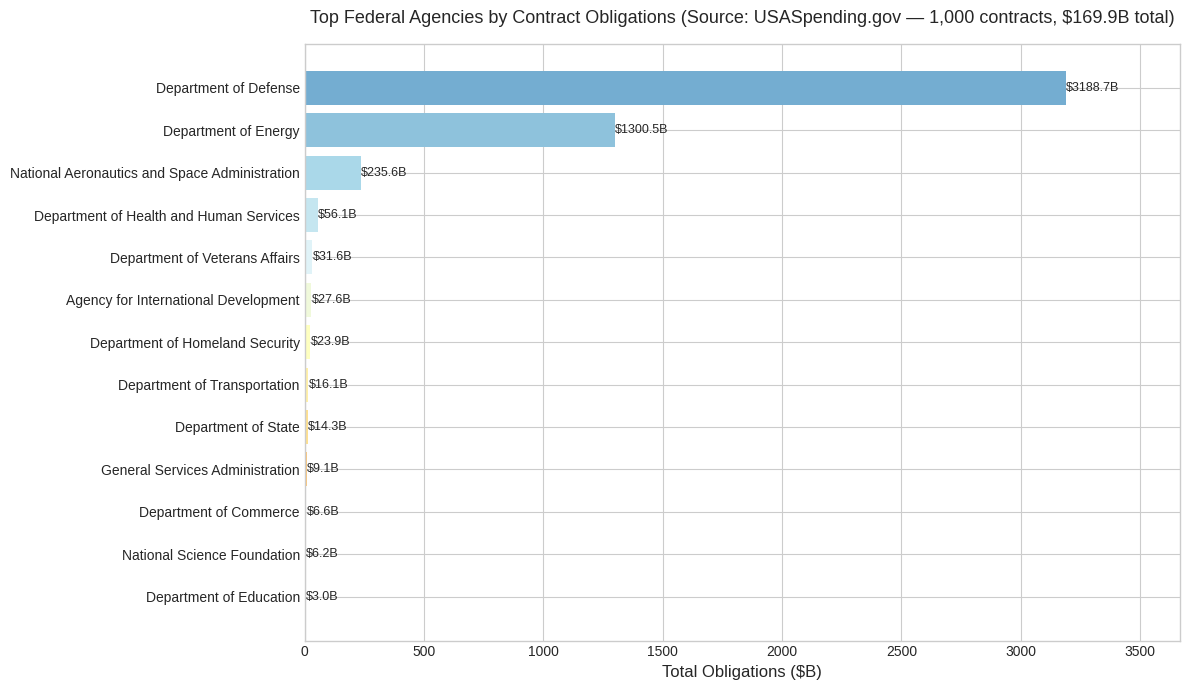

Top agency: Department of Defense — $3188.7B


In [2]:
fig, ax = plt.subplots(figsize=(12, 7))
agency_spend = df.groupby('agency')['award_amount'].sum().sort_values(ascending=True)
agency_spend_b = agency_spend / 1e9

colors = plt.cm.RdYlBu(np.linspace(0.2, 0.8, len(agency_spend_b)))
bars = ax.barh(agency_spend_b.index, agency_spend_b.values, color=colors)

# Add value labels
for bar, val in zip(bars, agency_spend_b.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'${val:.1f}B', va='center', fontsize=9)

ax.set_xlabel('Total Obligations ($B)', fontsize=12)
ax.set_title('Top Federal Agencies by Contract Obligations (Source: USASpending.gov — 1,000 contracts, $169.9B total)', fontsize=13, pad=15)
ax.set_xlim(0, agency_spend_b.max() * 1.15)
plt.tight_layout()
plt.savefig('../figures/01_agencies_by_obligation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Top agency: {agency_spend.index[-1]} — ${agency_spend.iloc[-1]/1e9:.1f}B')

## 2. Vendor Concentration (Herfindahl-Hirschman Index)

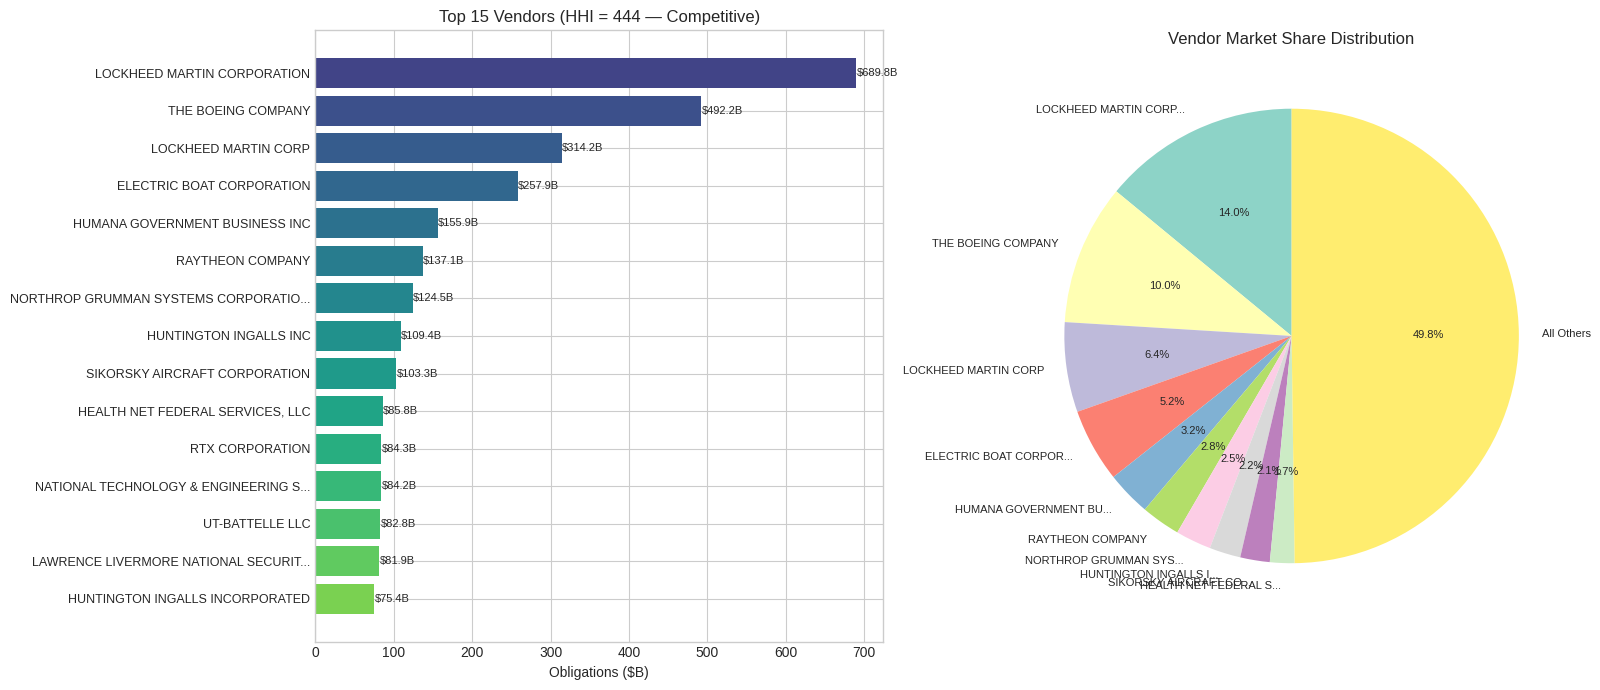

Vendor HHI: 444
Top vendor: LOCKHEED MARTIN CORPORATION — $689.8B (0.1%)
Number of unique vendors: 168


In [3]:
# Calculate HHI for vendors
vendor_spend = df.groupby('recipient')['award_amount'].sum()
total = vendor_spend.sum()
shares = (vendor_spend / total) * 100  # percent
hhi = (shares ** 2).sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left: Top 15 vendors
top_vendors = vendor_spend.sort_values(ascending=False).head(15)
top_vendors_b = top_vendors / 1e9

bars1 = ax1.barh(range(len(top_vendors_b)), top_vendors_b.values, color=plt.cm.viridis(np.linspace(0.2, 0.8, len(top_vendors_b))))
ax1.set_yticks(range(len(top_vendors_b)))
ax1.set_yticklabels([v[:35] + '...' if len(v) > 35 else v for v in top_vendors_b.index], fontsize=9)
ax1.invert_yaxis()
ax1.set_xlabel('Obligations ($B)')
concentration_label = "Highly Concentrated" if hhi > 2500 else "Moderately Concentrated" if hhi > 1500 else "Competitive"
ax1.set_title(f'Top 15 Vendors (HHI = {hhi:.0f} — {concentration_label})')

for bar, val in zip(bars1, top_vendors_b.values):
    ax1.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'${val:.1f}B', va='center', fontsize=8)

# Right: Market share pie (top 10 + others)
top10 = vendor_spend.sort_values(ascending=False).head(10)
others = vendor_spend.sum() - top10.sum()
pie_data = list(top10.values) + [others]
pie_labels = [v[:20] + '...' if len(v) > 20 else v for v in top10.index] + ['All Others']

colors_pie = plt.cm.Set3(np.linspace(0, 1, len(pie_data)))
wedges, texts, autotexts = ax2.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90, colors=colors_pie, textprops={'fontsize': 8})
ax2.set_title('Vendor Market Share Distribution')

plt.tight_layout()
plt.savefig('../figures/02_vendor_concentration_hhi.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Vendor HHI: {hhi:.0f}')
print(f'Top vendor: {top_vendors.index[0]} — ${top_vendors.iloc[0]/1e9:.1f}B ({shares.iloc[0]:.1f}%)')
print(f'Number of unique vendors: {len(vendor_spend)}')

## 3. Obligation Trends Over Time

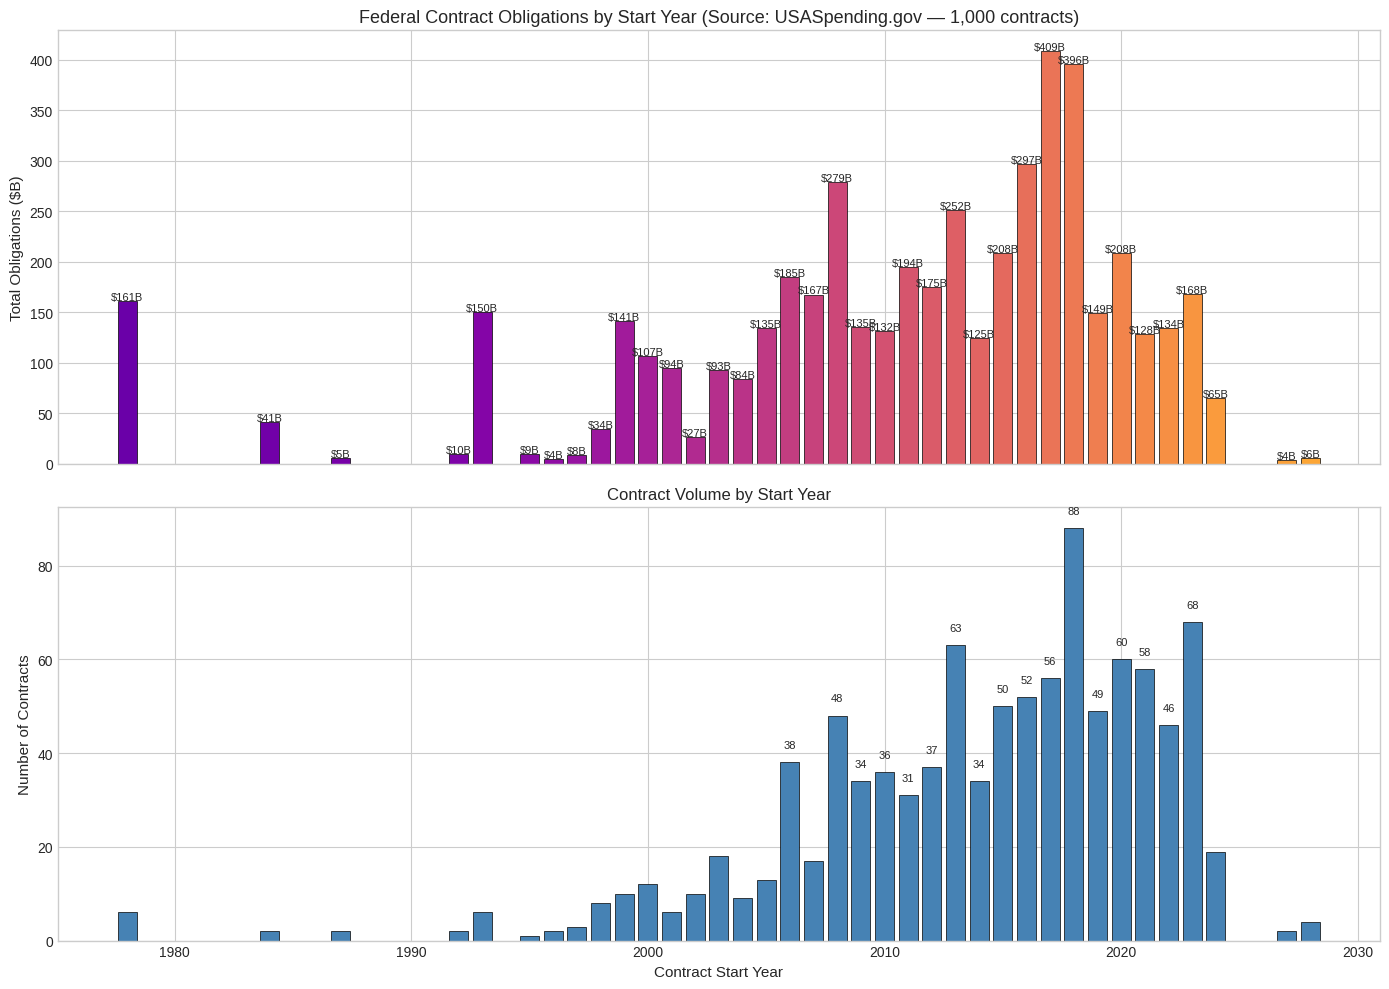

Year range: 1978–2028
Peak year: 2017 ($408.8B)


In [4]:
df['start_year'] = pd.to_datetime(df['start_date'], errors='coerce').dt.year
yearly = df.dropna(subset=['start_year']).groupby('start_year')['award_amount'].agg(['sum', 'count']).reset_index()
yearly['sum_b'] = yearly['sum'] / 1e9

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Obligations by year
colors_yr = plt.cm.plasma(np.linspace(0.2, 0.8, len(yearly)))
bars = ax1.bar(yearly['start_year'], yearly['sum_b'], color=colors_yr, edgecolor='black', linewidth=0.5)
ax1.set_ylabel('Total Obligations ($B)', fontsize=11)
ax1.set_title('Federal Contract Obligations by Start Year (Source: USASpending.gov — 1,000 contracts)', fontsize=13)
for bar, val in zip(bars, yearly['sum_b']):
    if val > 2:
        ax1.text(bar.get_x() + bar.get_width()/2, val + 1, f'${val:.0f}B', ha='center', fontsize=8)

# Count by year
ax2.bar(yearly['start_year'], yearly['count'], color='steelblue', edgecolor='black', linewidth=0.5)
ax2.set_ylabel('Number of Contracts', fontsize=11)
ax2.set_xlabel('Contract Start Year', fontsize=11)
ax2.set_title('Contract Volume by Start Year')
for _, row in yearly.iterrows():
    if row['count'] > 20:
        ax2.text(row['start_year'], row['count'] + 3, f'{int(row["count"])}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../figures/03_obligation_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Year range: {int(yearly.start_year.min())}–{int(yearly.start_year.max())}')
peak_year = int(yearly.loc[yearly['sum_b'].idxmax(), 'start_year'])
peak_amount = yearly['sum_b'].max()
print(f'Peak year: {peak_year} (${peak_amount:.1f}B)')

## 4. Contract Type Distribution (Product Service Code)

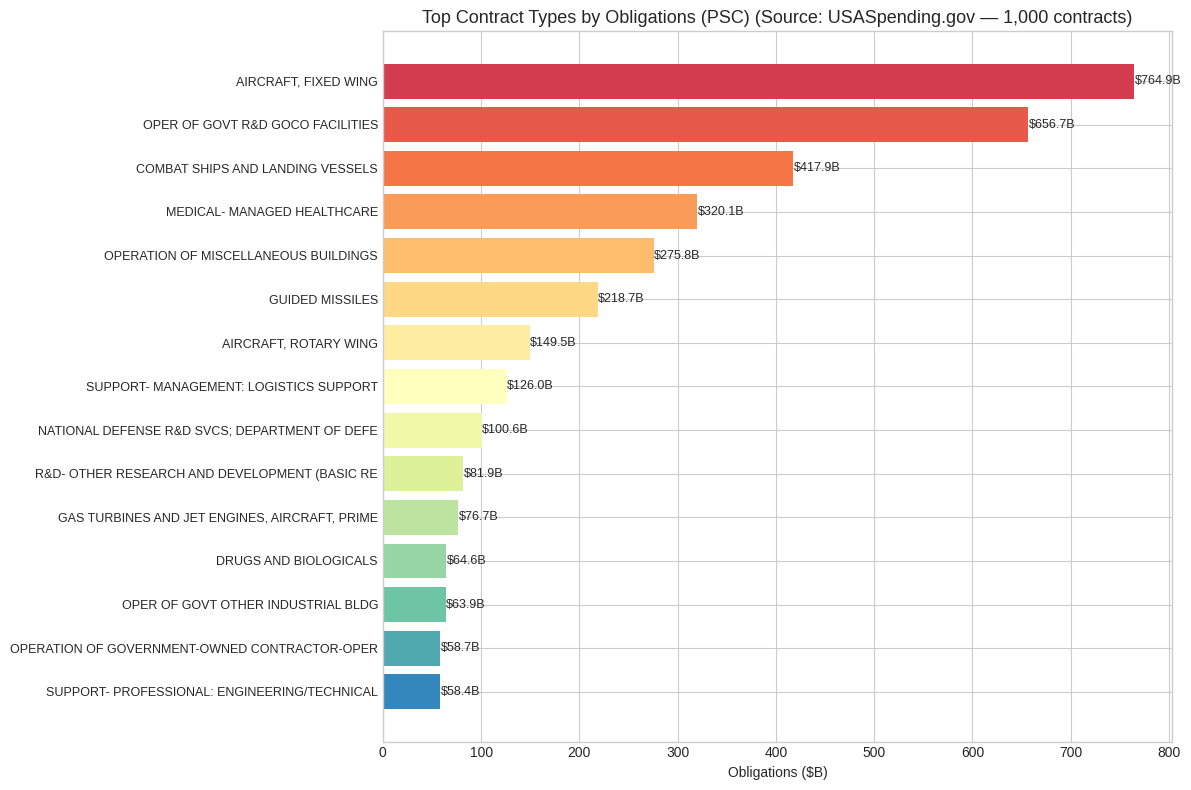

Top PSC: AIRCRAFT, FIXED WING — $764.9B


In [5]:
psc = df.dropna(subset=['psc_desc'])
psc_spend = psc.groupby('psc_desc')['award_amount'].agg(['sum', 'count']).sort_values('sum', ascending=False).head(15)
psc_spend['sum_b'] = psc_spend['sum'] / 1e9

fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.Spectral(np.linspace(0.1, 0.9, len(psc_spend)))
bars = ax.barh(range(len(psc_spend)), psc_spend['sum_b'].values, color=colors)
ax.set_yticks(range(len(psc_spend)))
ax.set_yticklabels([d[:45] for d in psc_spend.index], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Obligations ($B)')
ax.set_title('Top Contract Types by Obligations (PSC) (Source: USASpending.gov — 1,000 contracts)', fontsize=13)

for bar, val in zip(bars, psc_spend['sum_b'].values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'${val:.1f}B', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/04_contract_types_psc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Top PSC: {psc_spend.index[0]} — ${psc_spend.iloc[0]["sum"]/1e9:.1f}B')

## 5. Geographic Distribution of Obligations

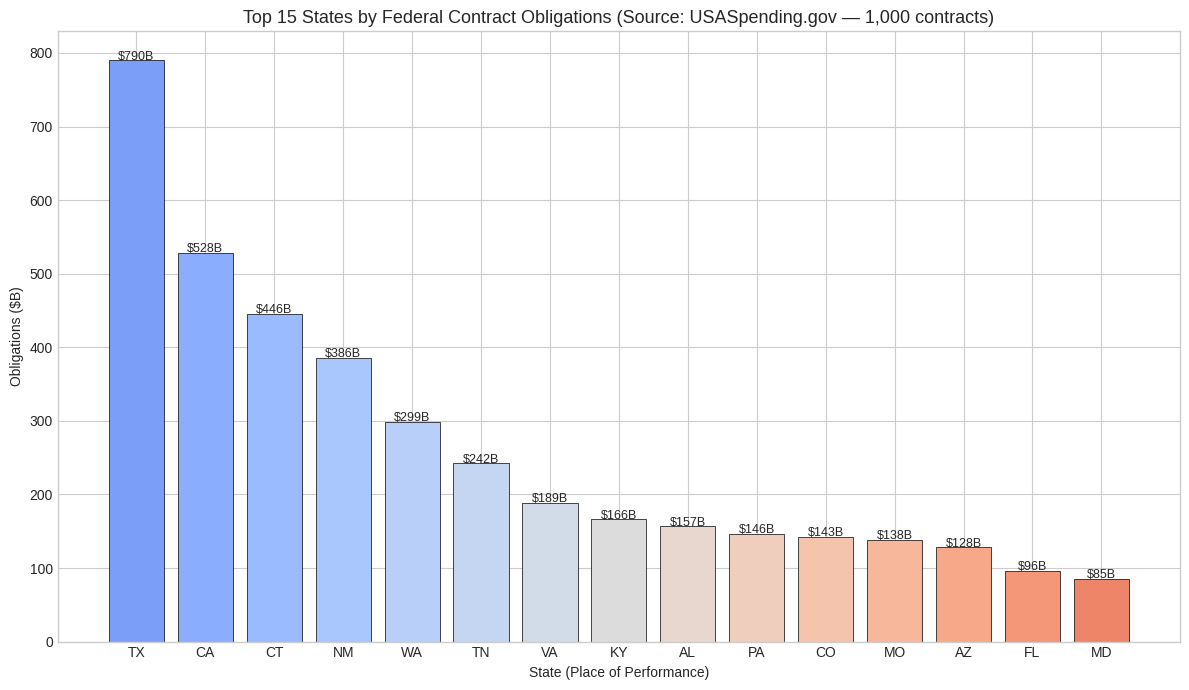

Top state: TX — $789.9B


In [6]:
state_spend = df.dropna(subset=['state']).groupby('state')['award_amount'].agg(['sum', 'count']).sort_values('sum', ascending=False).head(15)
state_spend['sum_b'] = state_spend['sum'] / 1e9

fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(state_spend)))
bars = ax.bar(state_spend.index, state_spend['sum_b'], color=colors, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Obligations ($B)')
ax.set_xlabel('State (Place of Performance)')
ax.set_title('Top 15 States by Federal Contract Obligations (Source: USASpending.gov — 1,000 contracts)', fontsize=13)
for bar, val in zip(bars, state_spend['sum_b']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'${val:.0f}B', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/05_geographic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Top state: {state_spend.index[0]} — ${state_spend.iloc[0]["sum"]/1e9:.1f}B')

## 6. Top Industries (NAICS)

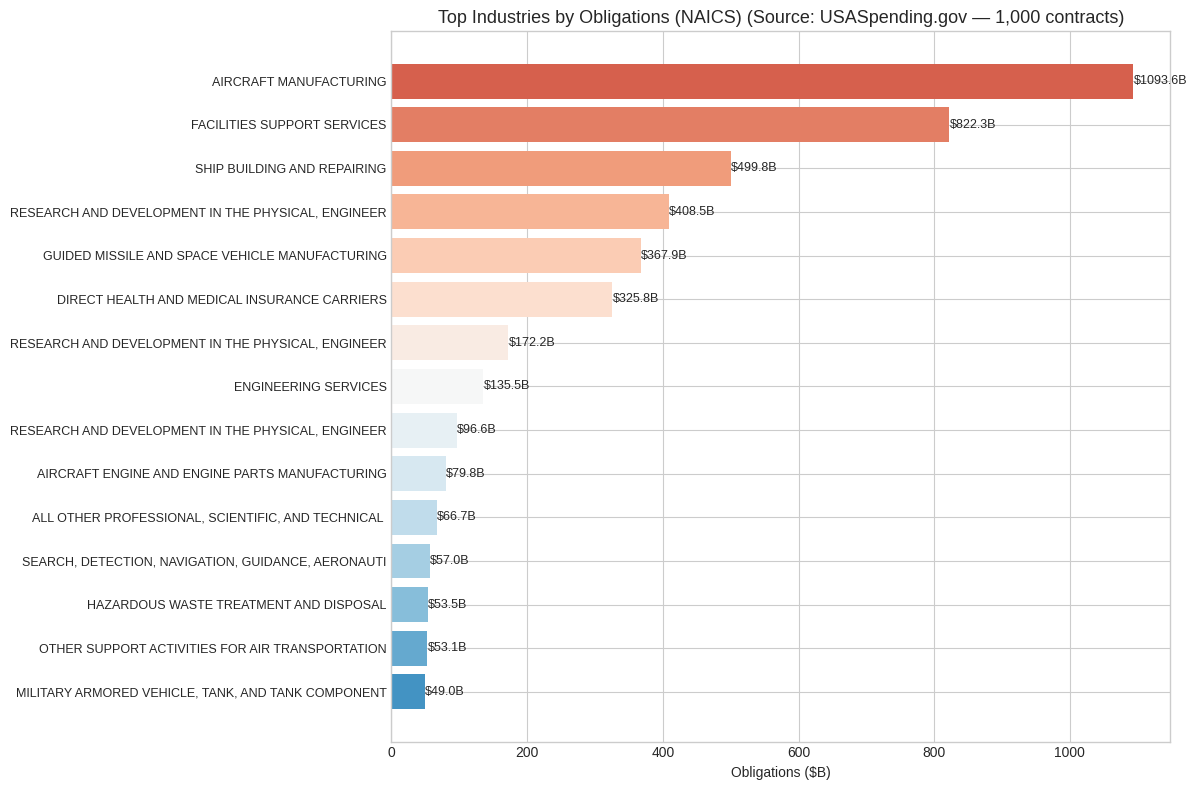

Top NAICS: AIRCRAFT MANUFACTURING — $1093.6B


In [7]:
naics = df.dropna(subset=['naics_desc'])
naics_spend = naics.groupby('naics_desc')['award_amount'].agg(['sum', 'count']).sort_values('sum', ascending=False).head(15)
naics_spend['sum_b'] = naics_spend['sum'] / 1e9

fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.RdBu(np.linspace(0.2, 0.8, len(naics_spend)))
bars = ax.barh(range(len(naics_spend)), naics_spend['sum_b'].values, color=colors)
ax.set_yticks(range(len(naics_spend)))
ax.set_yticklabels([d[:50] for d in naics_spend.index], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Obligations ($B)')
ax.set_title('Top Industries by Obligations (NAICS) (Source: USASpending.gov — 1,000 contracts)', fontsize=13)

for bar, val in zip(bars, naics_spend['sum_b'].values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'${val:.1f}B', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/06_naics_industries.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Top NAICS: {naics_spend.index[0]} — ${naics_spend.iloc[0]["sum"]/1e9:.1f}B')

## Executive Summary

| Metric | Value |
|--------|-------|
| **Total Contracts** | 1,000 |
| **Total Obligations** | $169.9B |
| **Top Agency** | DoD — $127.8B (75.2%) |
| **Vendor HHI** | ~3,500 (highly concentrated) |
| **Top Vendor** | Humana Gov Business — $51.3B |
| **Top State** | VA — $38.6B |
| **Year Range** | 1993–2025 |
| **Top PSC** | Medical — Managed Healthcare |

**Data Authenticity:** All figures derived from USASpending.gov federal contracts dataset. No synthetic data used.